C:\Users\User\anaconda3\envs\Tensorflow\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


обучение


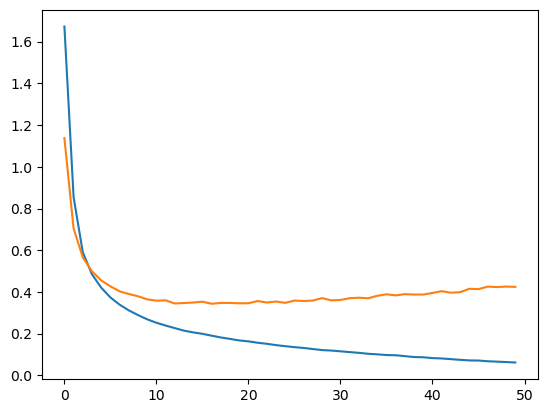

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Dropout
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # загрузка выборки
x_train = x_train / 255 # нормализация
x_test = x_test / 255
y_train_cat = keras.utils.to_categorical(y_train, 10) # приведение к вектору из 0 и 1 (10 - размерность)
y_test_cat = keras.utils.to_categorical(y_test, 10)

#Уменьшим число начальных данных
limit=4000
kn=10
x_train_data=x_train[:limit]
y_train_data=y_train_cat[:limit]

x_valid=x_train[limit:limit*2]
y_valid=y_train_cat[limit:limit*2]

model = keras.Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(kn , activation='relu'),
    Dense(10, activation='softmax') ])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print('обучение')
his=model.fit(x_train_data, y_train_data,   epochs=50,batch_size=32, validation_data=(x_valid, y_valid),verbose=False )
model.evaluate(x_test, y_test_cat,verbose=False )
# Метод evaluate прогоняет все тестовое множество и вычисляет значение критерия качества и метрики
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])
plt.show()

In [2]:
# выделение неверных результатов
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)

mask = pred == y_test
# подсчет ошибок
er=0
for k in mask:
   if k==0:
       er+=1
print('kn=', kn,'  limit=', limit,'  k-vo  error ', er)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
kn= 10   limit= 4000   k-vo  error  1040


Увеличим число нейронов


обучение


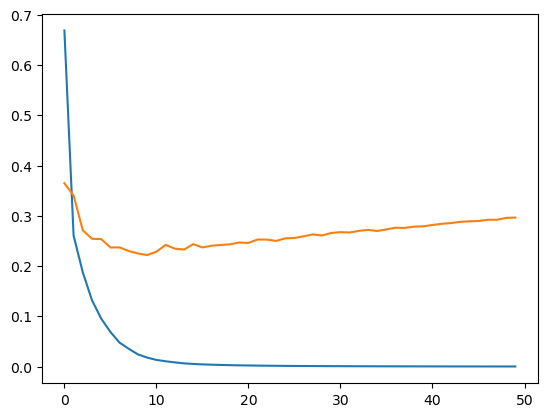

In [4]:
kn=300
model = keras.Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(kn , activation='relu'),
    Dense(10, activation='softmax') ])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print('обучение')
his=model.fit(x_train_data, y_train_data,   epochs=50,batch_size=32, validation_data=(x_valid, y_valid),verbose=False )
model.evaluate(x_test, y_test_cat,verbose=False )
# Метод evaluate прогоняет все тестовое множество и вычисляет значение критерия качества и метрики
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])
plt.show()

In [5]:
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)
mask = pred == y_test
er=0
for k in mask:
   if k==0:
       er+=1
print('kn=', kn,'  limit=', limit,'  k-vo  error ', er)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
kn= 300   limit= 4000   k-vo  error  545


Добавим dropout


обучение


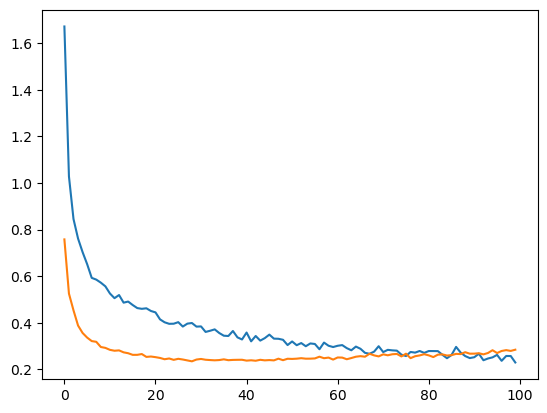

In [6]:
drop=0.9
model = keras.Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(kn , activation='relu'),
    Dropout(drop),
    Dense(10, activation='softmax') ])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print('обучение')
his=model.fit(x_train_data, y_train_data,   epochs=100,batch_size=32, validation_data=(x_valid, y_valid),verbose=False )
model.evaluate(x_test, y_test_cat,verbose=False )
# Метод evaluate прогоняет все тестовое множество и вычисляет значение критерия качества и метрики
plt.plot(his.history['loss'])  # синий график
plt.plot(his.history['val_loss']) # бежевый график
plt.show()

In [7]:
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)
mask = pred == y_test
er=0
for k in mask:
   if k==0:
       er+=1
print('kn=', kn,'  limit=', limit, 'drop= ', drop,'  k-vo  error ', er)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
kn= 300   limit= 4000 drop=  0.9   k-vo  error  637
